# Stage 2: URL Feature Classification
### Multimodal Phishing Detection — Group 15, Binus University

**Model:** XGBoost  
**Data:** PhiUSIIL_Phishing_URL_Dataset.csv (URL structural features)

## Cell 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, joblib, warnings
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
warnings.filterwarnings('ignore')

BASE       = os.path.abspath('..')
FIG_DIR    = os.path.join(BASE, 'result', 'figures')
METRIC_DIR = os.path.join(BASE, 'result', 'metrics')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(METRIC_DIR, exist_ok=True)
print('Libraries imported.')

Libraries imported.


## Cell 2: Load Dataset

In [2]:
DATA_PATH = os.path.join(BASE, 'data', 'PhiUSIIL_Phishing_URL_Dataset.csv')

URL_FEATURES = [
    'URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex',
    'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength',
    'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio',
    'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL',
    'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL',
    'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS'
]
LABEL_COL = 'label'  # 0=phishing, 1=legitimate

df = pd.read_csv(DATA_PATH, usecols=URL_FEATURES + [LABEL_COL], nrows=50000)
df = df.dropna().reset_index(drop=True)
print(f'Loaded: {len(df)} rows, {len(URL_FEATURES)} URL features')
print(df[LABEL_COL].value_counts().rename({0: 'Phishing', 1: 'Legitimate'}))
df.head()

Loaded: 50000 rows, 22 URL features
label
Legitimate    29374
Phishing      20626
Name: count, dtype: int64


,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,label
0,31,24,0,100.0,1.000000,0.522907,0.061933,3,1,0,...,0.581,0,0.0,0,0,0,1,0.032,1,1
1,23,16,0,100.0,0.666667,0.032650,0.050207,2,1,0,...,0.391,0,0.0,0,0,0,2,0.087,1,1
2,29,22,0,100.0,0.866667,0.028555,0.064129,2,2,0,...,0.517,0,0.0,0,0,0,2,0.069,1,1
3,26,19,0,100.0,1.000000,0.522907,0.057606,3,1,0,...,0.500,0,0.0,0,0,0,1,0.038,1,1
4,33,26,0,100.0,1.000000,0.079963,0.059441,3,1,0,...,0.606,0,0.0,0,0,0,1,0.030,1,1


## Cell 3: EDA — Label Distribution

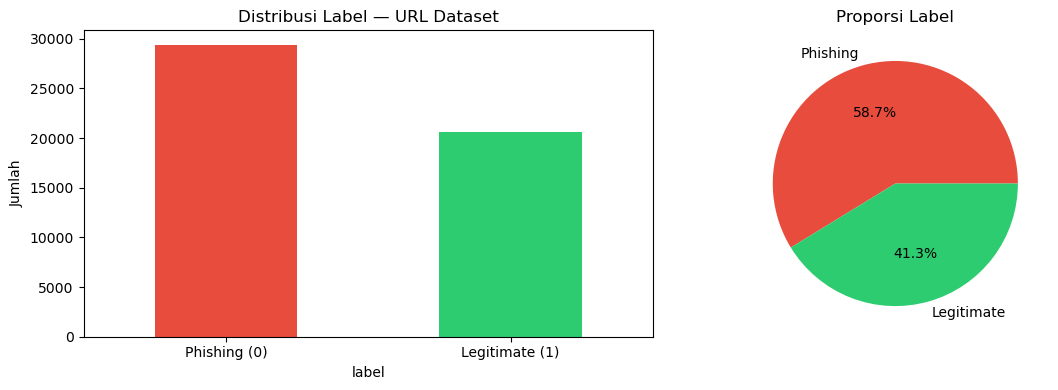

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df[LABEL_COL].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Distribusi Label — URL Dataset')
axes[0].set_xticklabels(['Phishing (0)', 'Legitimate (1)'], rotation=0)
axes[0].set_ylabel('Jumlah')
df[LABEL_COL].value_counts().plot(kind='pie', ax=axes[1],
    labels=['Phishing', 'Legitimate'], colors=['#e74c3c', '#2ecc71'], autopct='%1.1f%%')
axes[1].set_title('Proporsi Label')
axes[1].set_ylabel('')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'stage2_label_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## Cell 4: Train/Test Split

In [4]:
X = df[URL_FEATURES]
y = df[LABEL_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 40000 | Test: 10000


## Cell 5: Train XGBoost Model

In [5]:
model = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=42, eval_metric='logloss', verbosity=0
)
model.fit(X_train, y_train)
print('Model trained.')

Model trained.


## Cell 6: Evaluate Model

In [6]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

print('='*50)
print('HASIL EVALUASI -- STAGE 2: URL CLASSIFIER')
print('='*50)
print(f'Accuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1-Score  : {f1:.4f}')
print(classification_report(y_test, y_pred, target_names=['Phishing (0)', 'Legitimate (1)']))

stage2_metrics = {
    'Stage': 'Stage 2 - URL', 'Model': 'XGBoost',
    'Accuracy': round(accuracy, 4), 'Precision': round(precision, 4),
    'Recall': round(recall, 4), 'F1-Score': round(f1, 4)
}

HASIL EVALUASI -- STAGE 2: URL CLASSIFIER
Accuracy  : 0.9999 (99.99%)
Precision : 0.9999
Recall    : 0.9999
F1-Score  : 0.9999
                precision    recall  f1-score   support

  Phishing (0)       1.00      1.00      1.00      4125
Legitimate (1)       1.00      1.00      1.00      5875

      accuracy                           1.00     10000
     macro avg       1.00      1.00      1.00     10000
  weighted avg       1.00      1.00      1.00     10000



## Cell 7: Confusion Matrix

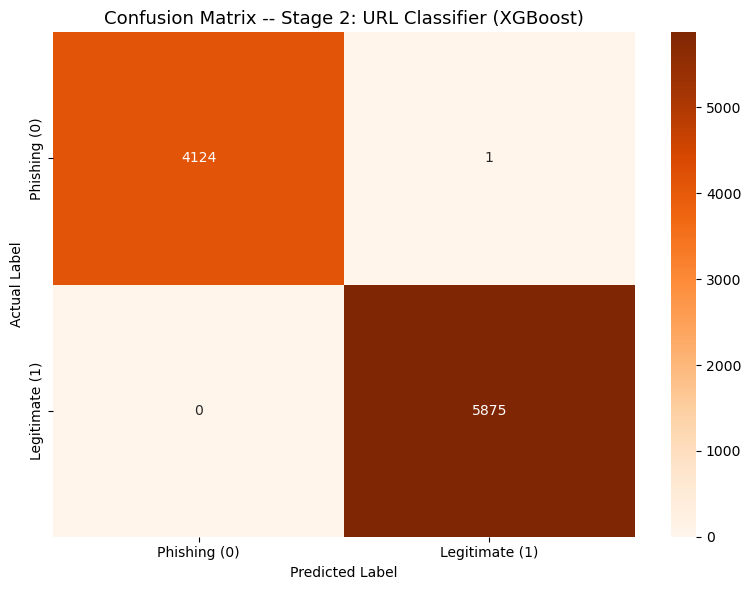

TN=4124  FP=1  FN=0  TP=5875


In [7]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
    xticklabels=['Phishing (0)', 'Legitimate (1)'],
    yticklabels=['Phishing (0)', 'Legitimate (1)'])
plt.title('Confusion Matrix -- Stage 2: URL Classifier (XGBoost)', fontsize=13)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'stage2_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')

## Cell 8: Feature Importance

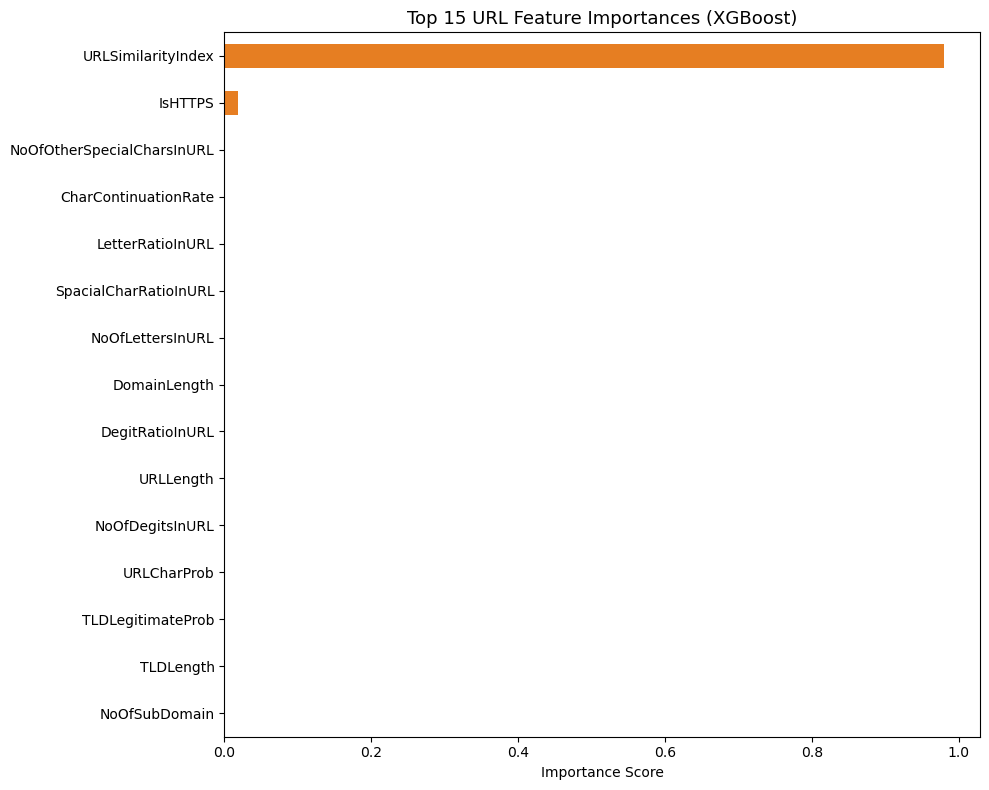

In [8]:
importances = pd.Series(model.feature_importances_, index=URL_FEATURES).sort_values(ascending=False)
plt.figure(figsize=(10, 8))
importances.head(15).plot(kind='barh', color='#e67e22')
plt.gca().invert_yaxis()
plt.title('Top 15 URL Feature Importances (XGBoost)', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'stage2_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

## Cell 9: Latency-Aware Simulation

In [9]:
THRESHOLD = 0.70
max_prob = y_prob.max(axis=1)
clear_phishing = ((y_pred == 0) & (max_prob >= THRESHOLD)).sum()
clear_legit    = ((y_pred == 1) & (max_prob >= THRESHOLD)).sum()
ambiguous      = (max_prob < THRESHOLD).sum()
total          = len(y_pred)

print(f'Confidence threshold : {THRESHOLD*100:.0f}%')
print(f'Langsung PHISHING    : {clear_phishing} ({clear_phishing/total*100:.1f}%)')
print(f'Langsung LEGITIMATE  : {clear_legit} ({clear_legit/total*100:.1f}%)')
print(f'AMBIGUOUS -> Stage 3 : {ambiguous} ({ambiguous/total*100:.1f}%)')
stage2_metrics['Ambiguous_pct'] = round(ambiguous / total, 4)

Confidence threshold : 70%
Langsung PHISHING    : 4124 (41.2%)
Langsung LEGITIMATE  : 5876 (58.8%)
AMBIGUOUS -> Stage 3 : 0 (0.0%)


## Cell 10: Save Model & Metrics

In [10]:
joblib.dump(model, os.path.join(METRIC_DIR, 'stage2_model_xgb.pkl'))
pd.DataFrame([stage2_metrics]).to_csv(os.path.join(METRIC_DIR, 'stage2_metrics.csv'), index=False)
print('stage2_model_xgb.pkl saved')
print('stage2_metrics.csv saved')
print('STAGE 2 SELESAI! Lanjut ke 03_html_classification.ipynb')

stage2_model_xgb.pkl saved
stage2_metrics.csv saved
STAGE 2 SELESAI! Lanjut ke 03_html_classification.ipynb
